In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("abdulvahap/music-instrunment-sounds-for-classification")

print("Path to dataset files:", path)

100%|██████████| 4.59G/4.59G [03:40<00:00, 22.3MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/abdulvahap/music-instrunment-sounds-for-classification/versions/1


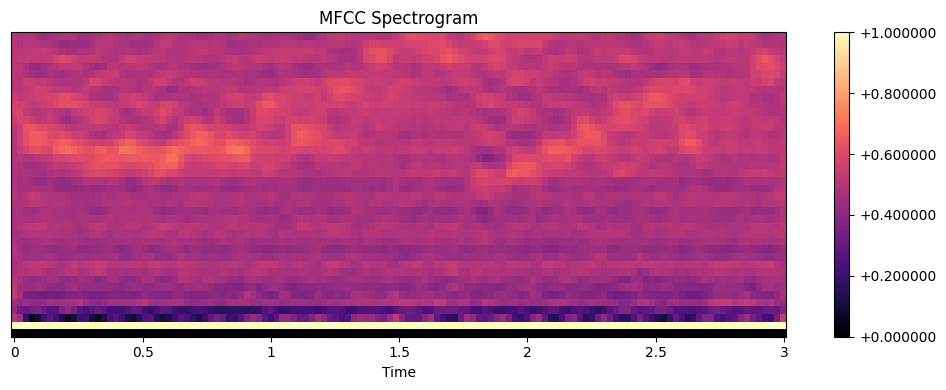

Fig. 2. Example MFCC spectrogram of a Trombone sample.


In [ ]:
def plot_mfcc_spectrogram(file_path, title="MFCC Spectrogram"):
    """Plots the MFCC spectrogram of an audio file."""
    try:
        y, sr = librosa.load(file_path)
        mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=40)

        # Clip extreme values to a reasonable range for visualization
        mfccs_clipped = np.clip(mfccs, -100, 100)

        # Normalize to 0-1 for plotting
        mfccs_norm = (mfccs_clipped - np.min(mfccs_clipped)) / (np.max(mfccs_clipped) - np.min(mfccs_clipped))

        plt.figure(figsize=(10, 4))
        librosa.display.specshow(mfccs_norm, x_axis='time', sr=sr)
        plt.colorbar(format='%+2f')
        plt.title(title)
        plt.tight_layout()
        plt.show()
        print(f"Fig. 2. Example MFCC spectrogram of a {file_path.split('/')[-2]} sample.")
    except Exception as e:
        print(f"Error loading or processing {file_path}: {e}")

# Select a random audio file from the list of files
random_file = random.choice(files)
plot_mfcc_spectrogram(random_file)


In [ ]:
import numpy as np
import glob
import matplotlib.pyplot as plt
# from skimage.color import rgb2grey # Not needed for audio
# from matplotlib.image import imread # Not needed for audio
#!pip install -q keras # Already installed
# from keras.models import Sequential # Already imported
# from keras.models import Sequential # Duplicate import
# from keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Activation, ReLU, Dropout # Already imported
# from tensorflow.keras.utils import to_categorical # Already imported
import librosa # Import librosa for audio processing
import os
import random
import pandas as pd # Import pandas to easily count class occurrences

# Define the desired number of classes and samples per class
num_classes_to_select = 20
samples_per_class = 1500

dataset_dir = "/root/.cache/kagglehub/datasets/abdulvahap/music-instrunment-sounds-for-classification/versions/1/music_dataset" # Updated dataset_dir

# Get all instrument directories
instrument_dirs = [d for d in glob.glob(f"{dataset_dir}/*") if os.path.isdir(d)]

# Select the first 'num_classes_to_select' directories
selected_instrument_dirs = instrument_dirs[:num_classes_to_select]

# Create a mapping of selected instrument names to labels (0-indexed)
class_names = [os.path.basename(d) for d in selected_instrument_dirs]
number_of_classes = len(class_names)
instruments = {name: i for i, name in enumerate(class_names)}

files = []
# Select 'samples_per_class' random .wav files from each selected instrument directory
for instrument_dir in selected_instrument_dirs:
    instrument_files = glob.glob(f"{instrument_dir}/*.wav")
    # Ensure we don't select more files than available
    num_to_select = min(samples_per_class, len(instrument_files))
    files.extend(random.sample(instrument_files, num_to_select))


np.random.shuffle(files)

data, labels = [], []

loaded = 0

print('Number of samples {0}'.format(len(files)))


for file in files:
  try:
    name = file.split('/')[-2]
    if name in instruments:

        y, sr = librosa.load(file)

        mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=40) # Example MFCC extraction

        # Pad or truncate MFCCs to a fixed size (important for CNN input)
        max_padding = 1000
        if mfccs.shape[1] < max_padding:
            pad_width = max_padding - mfccs.shape[1]
            mfccs = np.pad(mfccs, pad_width=((0, 0), (0, pad_width)), mode='constant')
        else:
            mfccs = mfccs[:, :max_padding]

        data.append(mfccs)
        labels.append(instruments[name])

        loaded += 1
        if loaded % 200 == 0:
            print(loaded)

  except Exception as e:
      print(f"Error loading {file}: {e}")


data, labels = np.array(data), np.array(labels)

# Split data
s_60p, s_20p = int(len(data) * 0.6), int(len(data) * 0.2)

X_train, y_train = data[:s_60p], labels[:s_60p] #60%
X_validation, y_validation = data[s_60p: s_60p + s_20p], labels[s_60p: s_60p + s_20p]  #20%
X_test, y_test = data[s_60p + s_20p:], labels[s_60p + s_20p:] #20%

print(X_train.shape, X_test.shape)

Number of samples 18499
200
400
600
800
1000
1200
1400
1600
1800
2000
2200
2400
2600
2800
3000
3200
3400
3600
3800
4000
4200
4400
4600
4800
5000
5200
5400
5600
5800
6000
6200
6400
6600
6800
7000
7200
7400
7600
7800
8000
8200
8400
8600
8800
9000
9200
9400
9600
9800
10000
10200
10400
10600
10800
11000
11200
11400
11600
11800
12000
12200
12400
12600
12800
13000
13200
13400
13600
13800
14000
14200
14400
14600
14800
15000
15200
15400
15600
15800
16000
16200
16400
16600
16800
17000
17200
17400
17600
17800
18000
18200
18400
(11099, 40, 1000) (3701, 40, 1000)


In [ ]:
print(X_validation.shape, y_validation.shape)

(3781, 40, 1000) (3781,)


In [ ]:
from tensorflow.keras.utils import to_categorical
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Activation, Dropout

# The shape of MFCCs is (samples, n_mfcc, max_padding)
# For CNN input, we need a shape of (samples, n_mfcc, max_padding, 1)
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], X_train.shape[2], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], X_test.shape[2], 1)
X_validation = X_validation.reshape(X_validation.shape[0], X_validation.shape[1], X_validation.shape[2], 1)

# One-hot encode the labels
y_train_one_hot = to_categorical(y_train, num_classes=number_of_classes)
y_validation_one_hot = to_categorical(y_validation, num_classes=number_of_classes)
y_test_one_hot = to_categorical(y_test, num_classes=number_of_classes)


print('Dataset has been loaded succesfully.')
print(X_train.shape, y_train_one_hot.shape)
print(X_validation.shape, y_validation_one_hot.shape)

print(X_train.shape[1:])

epochs = 30

model = Sequential([
        Conv2D(32, (3, 3), input_shape=X_train.shape[1:]),
        Activation('relu'),
        Conv2D(32, (3, 3)),
        Activation('relu'),
        MaxPooling2D(pool_size=(2, 2)),
        Dropout(0.25),

        Conv2D(64, (3,3), padding='same'),
        Activation('relu'),
        Conv2D(64, (3, 3)),
        Activation('relu'),
        MaxPooling2D(pool_size=(2, 2)),
        Dropout(0.25),

        Conv2D(128, (3, 3), padding='same'),
        Activation('relu'),
        Conv2D(128, (3, 3)),
        Activation('relu'),
        MaxPooling2D(pool_size=(2, 2)),
        Dropout(0.25),

        Flatten(),
        Dense(128),
        Activation('relu'),
        Dropout(0.5),
        Dense(number_of_classes),
        Activation('softmax')
    ])

model.compile('adam', loss='categorical_crossentropy', metrics=['accuracy'])
print(model.summary())

print('Fitting started...')
history = model.fit(X_train, y_train_one_hot, epochs=epochs, validation_data=(X_validation, y_validation_one_hot))

Dataset has been loaded succesfully.
(11343, 40, 1000, 1) (11343, 20)
(3781, 40, 1000, 1) (3781, 20)
(40, 1000, 1)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_24 (Conv2D)              │ (None, 38, 998, 32)    │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_32 (Activation)      │ (None, 38, 998, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_25 (Conv2D)              │ (None, 36, 996, 32)    │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_33 (Activation)      │ (None, 36, 996, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 18, 498, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 18, 498, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_26 (Conv2D)              │ (None, 18, 498, 64)    │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_34 (Activation)      │ (None, 18, 498, 64)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_27 (Conv2D)              │ (None, 16, 496, 64)    │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_35 (Activation)      │ (None, 16, 496, 64)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 8, 248, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 8, 248, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_28 (Conv2D)              │ (None, 8, 248, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_36 (Activation)      │ (None, 8, 248, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_29 (Conv2D)              │ (None, 6, 246, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_37 (Activation)      │ (None, 6, 246, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 3, 123, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 3, 123, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 47232)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │     6,045,824 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_38 (Activation)      │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 20)             │         2,580 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_39 (Activation)      │ (None, 20)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,334,836 (24.17 MB)

 Trainable params: 6,334,836 (24.17 MB)

 Non-trainable params: 0 (0.00 B)

None
Fitting started...
Epoch 1/30
355/355 ━━━━━━━━━━━━━━━━━━━━ 56s 136ms/step - accuracy: 0.3332 - loss: 2.2866 - val_accuracy: 0.7696 - val_loss: 0.7541
Epoch 2/30
355/355 ━━━━━━━━━━━━━━━━━━━━ 34s 95ms/step - accuracy: 0.7628 - loss: 0.7781 - val_accuracy: 0.8551 - val_loss: 0.4873
Epoch 3/30
355/355 ━━━━━━━━━━━━━━━━━━━━ 33s 94ms/step - accuracy: 0.8440 - loss: 0.5045 - val_accuracy: 0.9008 - val_loss: 0.3310
Epoch 4/30
355/355 ━━━━━━━━━━━━━━━━━━━━ 33s 94ms/step - accuracy: 0.8824 - loss: 0.3941 - val_accuracy: 0.9339 - val_loss: 0.2284
Epoch 5/30
355/355 ━━━━━━━━━━━━━━━━━━━━ 33s 94ms/step - accuracy: 0.9058 - loss: 0.2993 - val_accuracy: 0.9315 - val_loss: 0.2404
Epoch 6/30
355/355 ━━━━━━━━━━━━━━━━━━━━ 33s 94ms/step - accuracy: 0.9294 - loss: 0.2493 - val_accuracy: 0.9439 - val_loss: 0.1854
Epoch 7/30
355/355 ━━━━━━━━━━━━━━━━━━━━ 33s 94ms/step - accuracy: 0.9288 - loss: 0.2480 - val_accuracy: 0.9527 - val_loss: 0.1744
Epoch 8/30
355/355 ━━━━━━━━━━━━━━━━━━━━ 33s 94ms/step - accuracy:

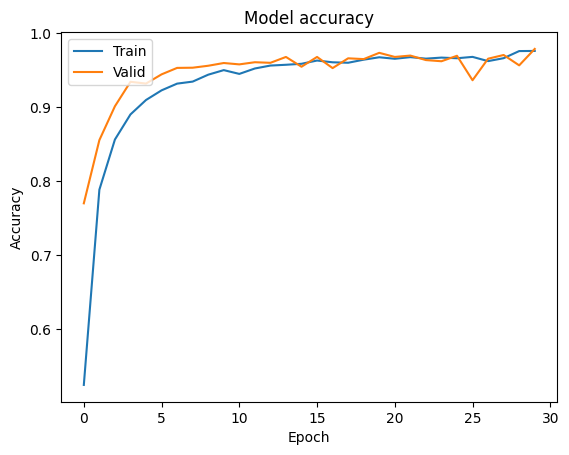

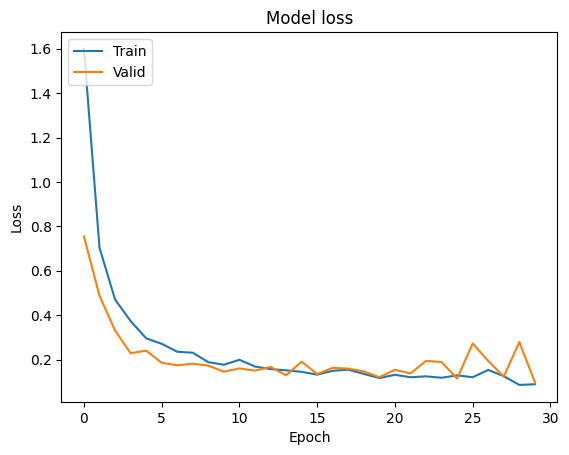

119/119 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.9813 - loss: 0.0782
Test Loss: 0.0855
Test Accuracy: 0.9807
119/119 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step

Classification Report:
              precision    recall  f1-score   support

      Violin       0.91      0.98      0.94       110
    Clarinet       0.96      0.97      0.96       127
     Ukulele       0.98      0.99      0.99       183
       Dobro       1.00      0.99      0.99       100
     Shakers       1.00      1.00      1.00       275
    Drum_set       1.00      1.00      1.00       306
   Floor_Tom       1.00      0.93      0.96        87
    Trombone       0.96      0.99      0.98       303
    Mandolin       0.98      0.99      0.99       281
       Banjo       0.98      1.00      0.99       281
   Saxophone       0.95      0.75      0.84        95
     cowbell       1.00      1.00      1.00       130
    Keyboard       1.00      1.00      1.00       317
 Bass_Guitar       1.00      1.00      1.00       300
       

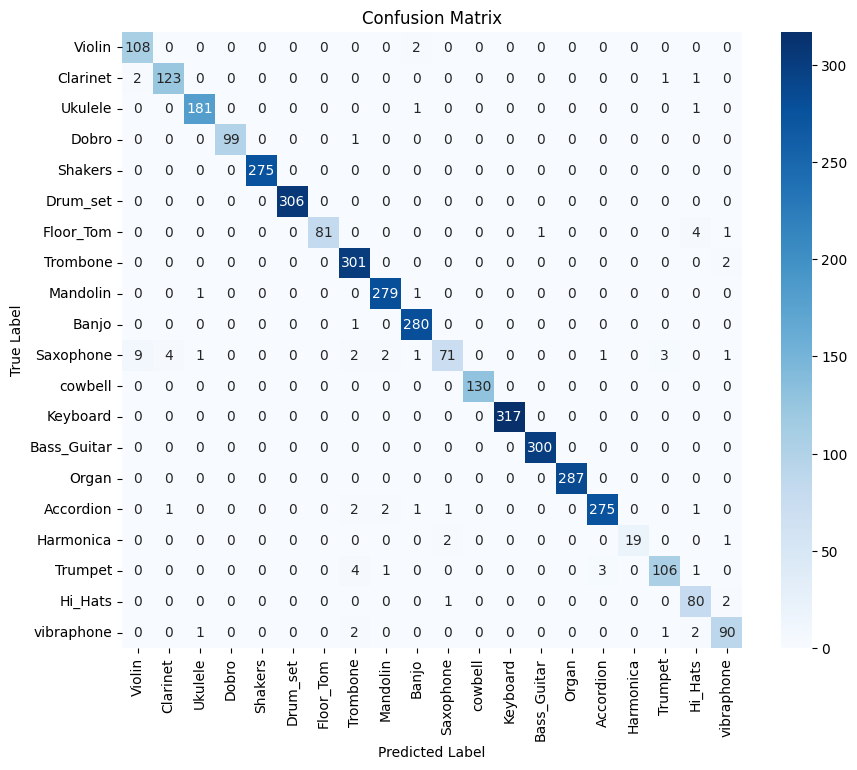

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

#model accuracy
# print(history.history) # Uncomment this line if you want to see the raw history data
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Valid'], loc='upper left')
plt.show()

#model loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Valid'], loc='upper left')
plt.show()

scores = model.evaluate(X_test, to_categorical(y_test), verbose=1)
print(f"Test Loss: {scores[0]:.4f}")
print(f"Test Accuracy: {scores[1]:.4f}")

# Get predictions for classification report and confusion matrix
y_pred = np.argmax(model.predict(X_test), axis=1)

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=class_names))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
scores = model.evaluate(X_test, to_categorical(y_test), verbose=1)
print(scores)

119/119 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.9813 - loss: 0.0782
[0.08551730960607529, 0.9806929230690002]


In [ ]:
model.save('model_v1.h5')
